## LangGraph

In [20]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [21]:
# define custom state in langgraph

class SimpleState(TypedDict):
    input_text: str
    output_text: str

In [22]:
SimpleState(input_text="Hello", output_text="HELLO")

{'input_text': 'Hello', 'output_text': 'HELLO'}

### Custom node

In [23]:
def process_text(state: SimpleState) -> SimpleState:
    print(f"State [process_text]: {state}")
    output_text = state["input_text"].upper()
    return {"output_text": output_text}

# we do not have to return the full state, we can partially update and return partial state

In [24]:
state = {
    "input_text": "Hello",
    "output_text": "",
}
process_text(state)

State [process_text]: {'input_text': 'Hello', 'output_text': ''}


{'output_text': 'HELLO'}

In [25]:
def add_prefix(state: SimpleState) -> SimpleState:
    print(f"State [add_prefix]: {state}")
    current_text = state["output_text"]
    prefix_text = f"I have added simple prefix with {current_text}"
    return {"output_text": prefix_text}

In [26]:
add_prefix(process_text(state))

State [process_text]: {'input_text': 'Hello', 'output_text': ''}
State [add_prefix]: {'output_text': 'HELLO'}


{'output_text': 'I have added simple prefix with HELLO'}

In [27]:
def add_suffix(state: SimpleState) -> SimpleState:
    print(f"State [add_suffix]: {state}")
    current_text = state["output_text"]
    prefix_text = f"{current_text} I have added simple suffix"
    return {"output_text": prefix_text}

In [28]:
add_suffix(add_prefix(process_text(state)))

State [process_text]: {'input_text': 'Hello', 'output_text': ''}
State [add_prefix]: {'output_text': 'HELLO'}
State [add_suffix]: {'output_text': 'I have added simple prefix with HELLO'}


{'output_text': 'I have added simple prefix with HELLO I have added simple suffix'}

In [29]:
def create_simple_graph():
    builder = StateGraph(SimpleState)
    
    builder.add_node("process_text", process_text)
    builder.add_node("add_prefix", add_prefix)
    builder.add_node("add_suffix", add_suffix)
    
    builder.add_edge(START, "process_text")
    builder.add_edge("process_text", "add_prefix")
    builder.add_edge("add_prefix", "add_suffix")
    builder.add_edge("add_suffix", END)
    
    graph = builder.compile()
    return graph

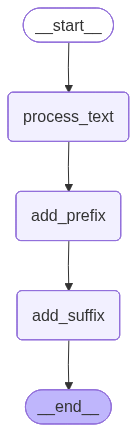

In [30]:
graph = create_simple_graph()
graph

In [31]:
initial_state = {
    "input_text": "Hello",
    "output_text": ""
}
final_state = graph.invoke(initial_state)
final_state

State [process_text]: {'input_text': 'Hello', 'output_text': ''}
State [add_prefix]: {'input_text': 'Hello', 'output_text': 'HELLO'}
State [add_suffix]: {'input_text': 'Hello', 'output_text': 'I have added simple prefix with HELLO'}


{'input_text': 'Hello',
 'output_text': 'I have added simple prefix with HELLO I have added simple suffix'}